## 3. Exploratory data analysis

In [3]:
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [4]:
df = pd.read_csv('../data/cleared-combine-21-23.csv',index_col = 'time', parse_dates = True)
df.head()

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,1,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,1,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,1,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,1,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [20]:
weather = df.iloc[:,1:9]

In [21]:
weather.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco
count,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000
mean,16.715251,10.145323,69.027588,0.048969,160.748782,9.934148,1015.323246,2.690373
std,4.205286,6.234503,19.666028,0.411796,109.163725,7.117350,3.837478,1.878776
min,4.000000,-17.300000,6.000000,0.000000,0.000000,0.000000,996.800000,1.000000
25%,13.900000,7.300000,60.000000,0.000000,50.000000,5.400000,1012.800000,1.000000
50%,16.700000,11.700000,74.000000,0.000000,210.000000,9.400000,1015.000000,2.000000
75%,19.400000,15.000000,84.000000,0.000000,250.000000,14.800000,1017.800000,3.000000
max,40.700000,28.900000,100.000000,10.700000,360.000000,59.400000,1028.900000,18.000000


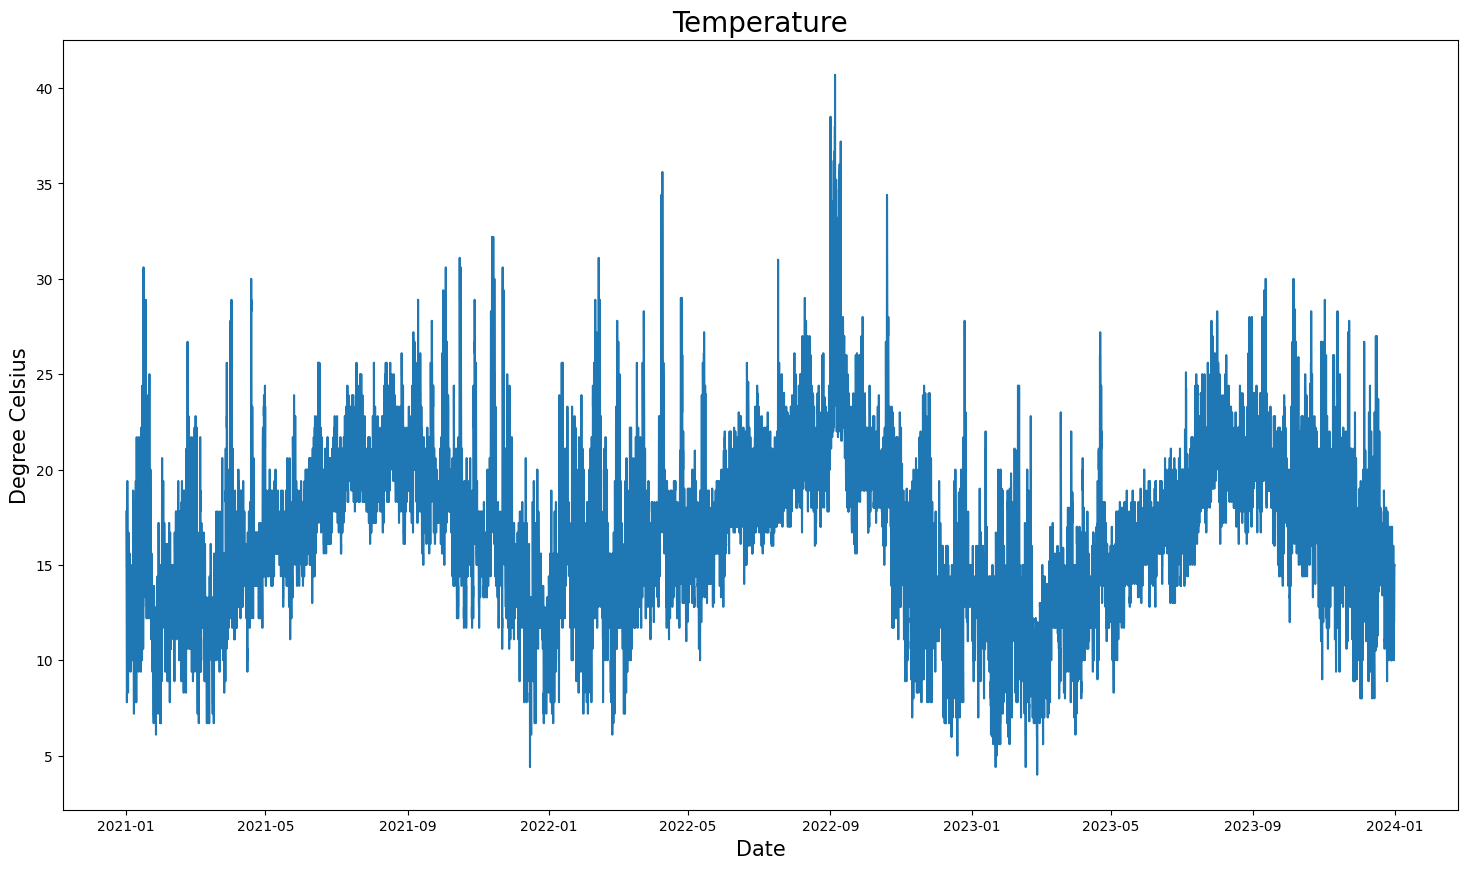

In [7]:
plt.figure(figsize = (18,10))
plt.plot(weather['temp'])

plt.title('Temperature', size = 20)
plt.xlabel('Date', size = 15)
plt.ylabel('Degree Celsius', size = 15);

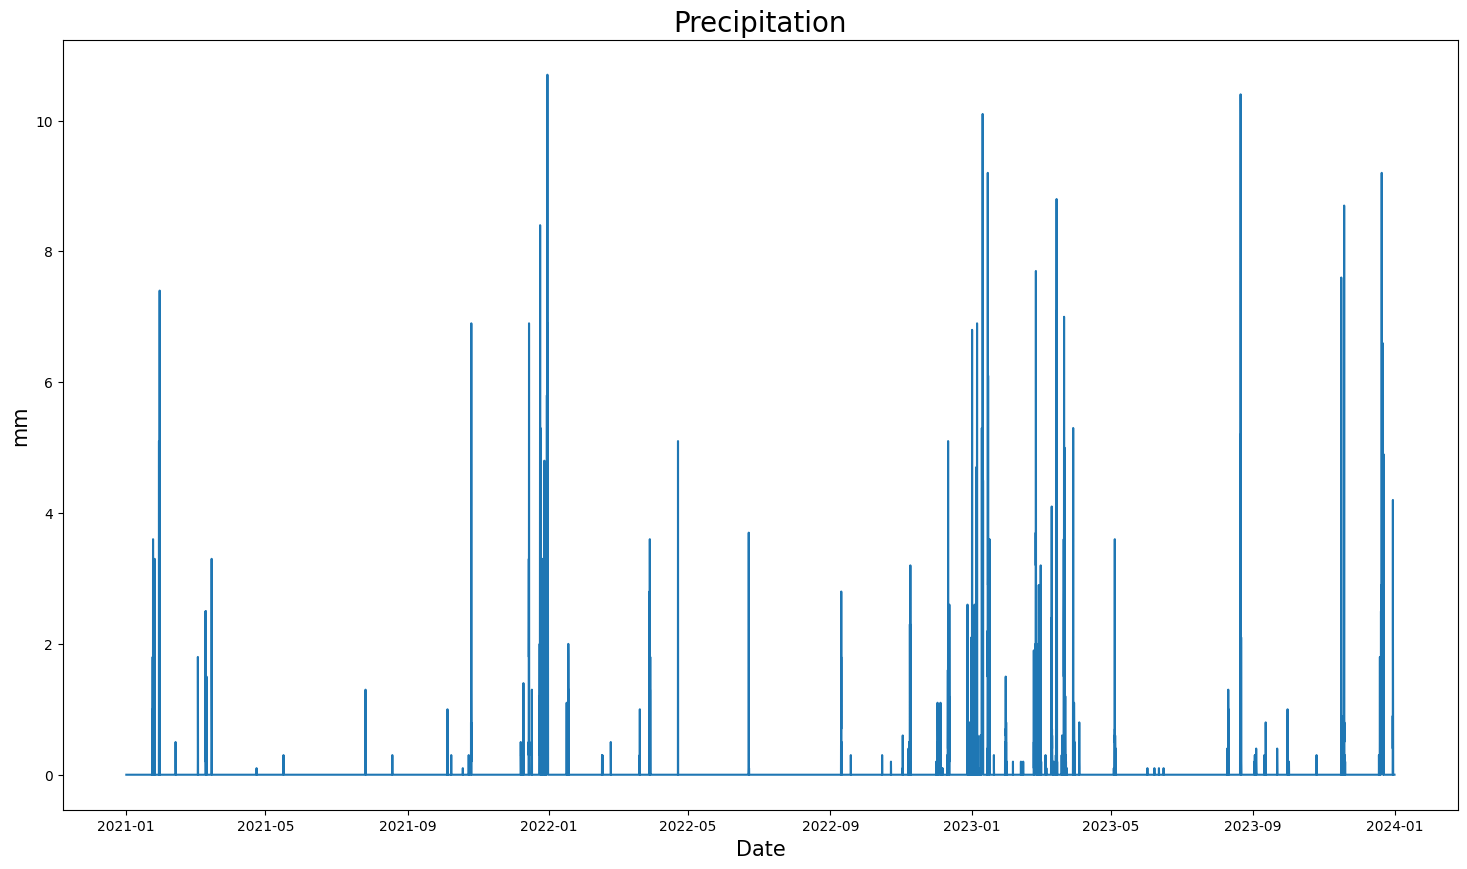

In [13]:
plt.figure(figsize = (18,10))
plt.plot(weather['prcp'])

plt.title('Precipitation', size = 20)
plt.xlabel('Date', size = 15)
plt.ylabel('mm', size = 15);

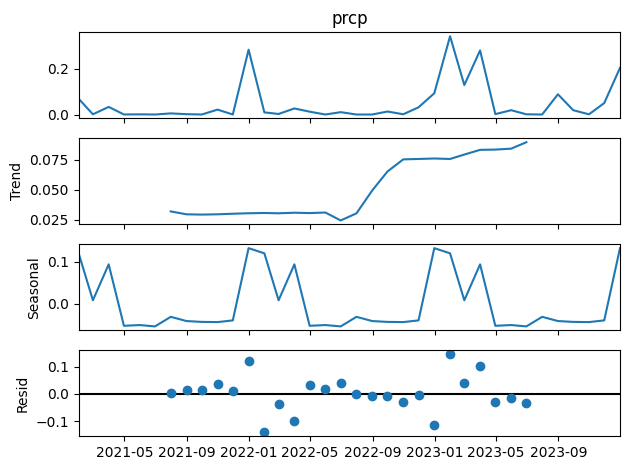

In [14]:
montly_prcp = weather['prcp'].resample('ME').mean()
decomp = seasonal_decompose(montly_prcp)
decomp.plot();

In [15]:
weather['coco'].value_counts()

coco
1.0     7381
2.0     7145
3.0     6516
5.0     3290
4.0      843
7.0      362
9.0      318
8.0      290
17.0      82
6.0       22
18.0      12
11.0       8
10.0       8
12.0       3
Name: count, dtype: int64

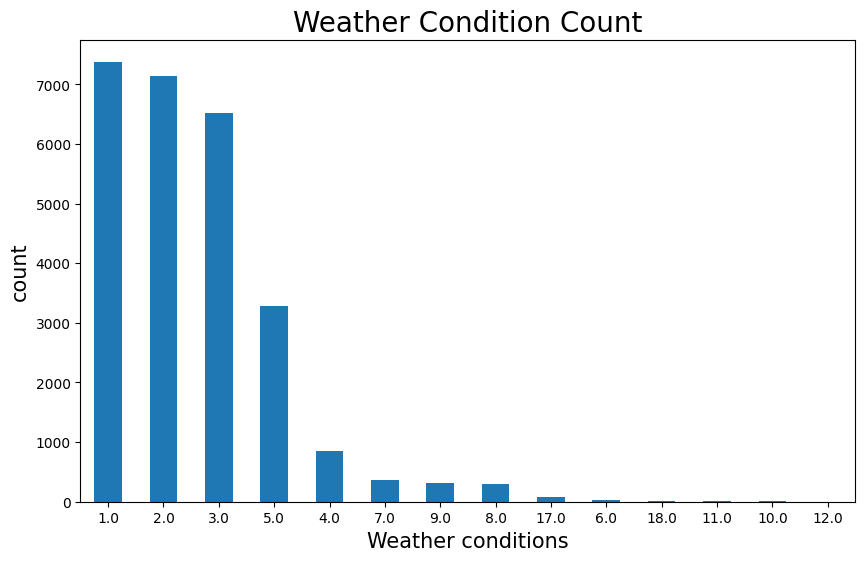

In [16]:
plt.figure(figsize = (10,6))
weather['coco'].value_counts().plot(kind='bar')

plt.title('Weather Condition Count', size = 20)
plt.xticks(rotation = 0)
plt.xlabel('Weather conditions', size = 15)
plt.ylabel('count', size = 15);

In [27]:
# randomly choose a station to analyze 
random.seed(42)
random_station = random.choice(df.columns[9:])
random_station

'717801'

In [28]:
station = df[random_station]
station.describe()

count    26280.000000
mean      5426.564784
std       2503.054379
min        191.000000
25%       3392.750000
50%       5753.000000
75%       7360.000000
max      14691.000000
Name: 717801, dtype: float64

### Seasonal decomposition

In [12]:
# hourly
# hourly plot is not readable

In [13]:
# plt.figure(figsize = (18,10))
# plt.plot(station)

# plt.title('Hourly Traffic Volume for Station 761455', size = 20)
# plt.xlabel('Date', size = 15)
# plt.ylabel('Traffic count', size = 15);

In [14]:
# decomp = seasonal_decompose(station)
# decomp.plot();

In [15]:
# daily
day_sample = station.resample('d').mean()

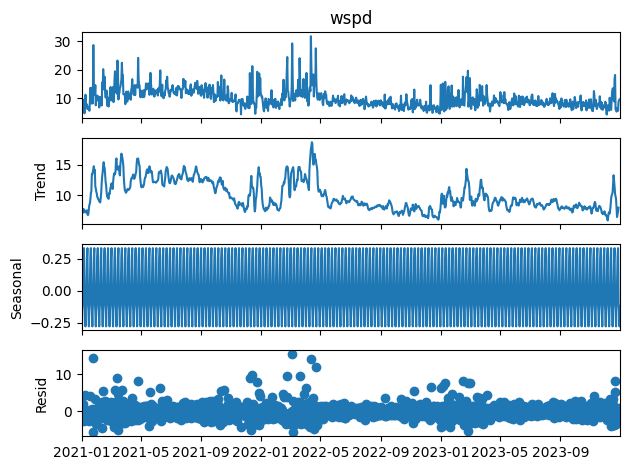

In [16]:
decomp = seasonal_decompose(day_sample)
decomp.plot();

In [17]:
# weekly
week_sample = station.resample('W').mean()

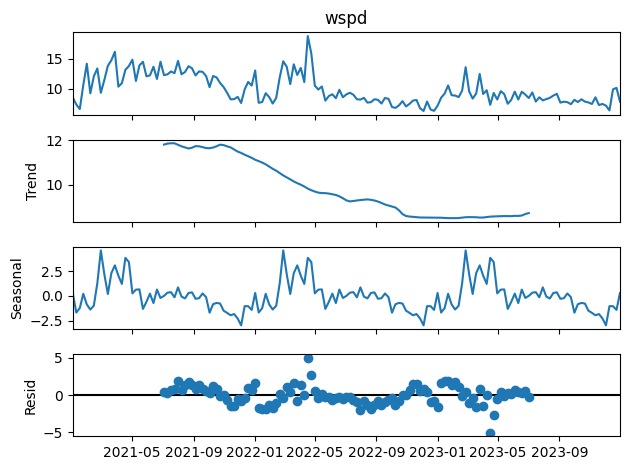

In [18]:
decomp = seasonal_decompose(week_sample)
decomp.plot();

In [19]:
# monthly
month_sample = station.resample('ME').mean()

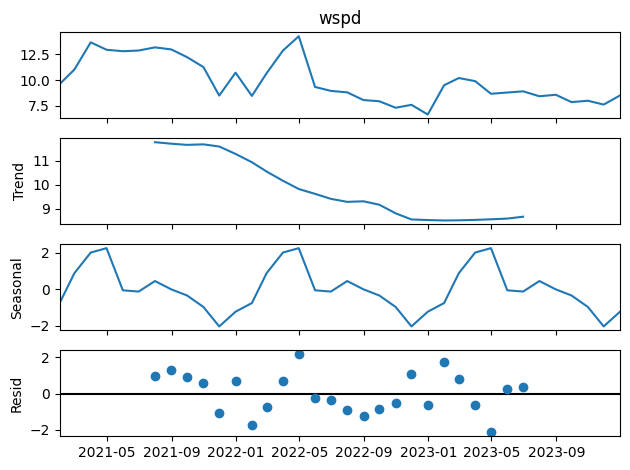

In [20]:
decomp = seasonal_decompose(month_sample)
decomp.plot();

### Correlation

In [21]:
df.corr().round(2)

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,717696,...,717819,717823,767367,717825,717827,771808,771767,772011,772024,isholiday
temp,1.00,0.40,-0.24,-0.10,0.26,0.21,-0.36,-0.12,-0.12,-0.13,...,0.01,0.02,-0.04,-0.05,-0.08,-0.07,-0.05,-0.11,-0.21,-0.02
dwpt,0.40,1.00,0.76,0.02,0.10,-0.01,-0.55,0.18,-0.02,-0.02,...,0.03,0.01,-0.03,-0.01,-0.04,-0.07,-0.06,-0.07,-0.06,-0.08
rhum,-0.24,0.76,1.00,0.12,-0.10,-0.20,-0.34,0.31,0.08,0.08,...,0.03,0.01,0.01,0.04,0.03,-0.01,-0.03,0.02,0.11,-0.06
prcp,-0.10,0.02,0.12,1.00,-0.04,0.07,-0.08,0.38,-0.01,-0.02,...,-0.04,-0.03,-0.03,0.00,0.02,-0.02,-0.05,-0.01,-0.02,0.02
wdir,0.26,0.10,-0.10,-0.04,1.00,0.60,-0.14,-0.02,-0.34,-0.35,...,-0.21,-0.24,-0.25,-0.30,-0.30,-0.22,-0.16,-0.28,-0.34,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771808,-0.07,-0.07,-0.01,-0.02,-0.22,-0.18,0.12,0.07,0.80,0.83,...,0.80,0.82,0.79,0.82,0.82,1.00,0.93,0.82,0.77,-0.02
771767,-0.05,-0.06,-0.03,-0.05,-0.16,-0.13,0.10,0.04,0.69,0.72,...,0.77,0.76,0.76,0.72,0.71,0.93,1.00,0.76,0.68,-0.03
772011,-0.11,-0.07,0.02,-0.01,-0.28,-0.26,0.10,0.08,0.84,0.86,...,0.78,0.82,0.80,0.86,0.85,0.82,0.76,1.00,0.86,-0.03
772024,-0.21,-0.06,0.11,-0.02,-0.34,-0.38,0.12,0.06,0.86,0.89,...,0.66,0.67,0.68,0.76,0.77,0.77,0.68,0.86,1.00,-0.02


Correlation between stations are usually strong but correlation between stations and weather columns are low and some are negatives, which suggests that weater condition may not have very stong influence on traffic flow.

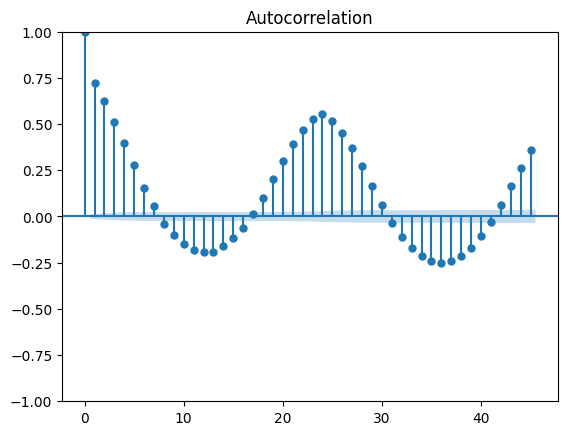

In [22]:
plot_acf(station);

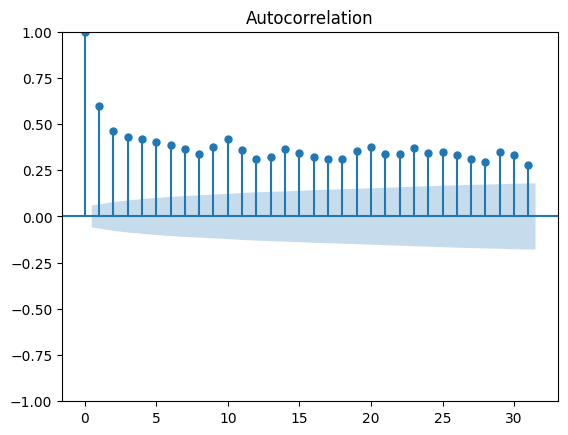

In [23]:
plot_acf(day_sample);

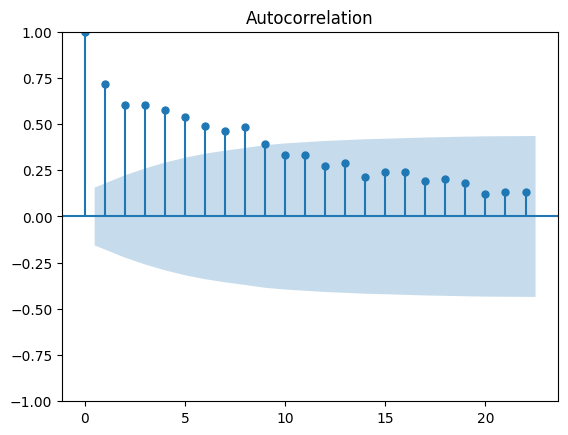

In [24]:
plot_acf(week_sample);

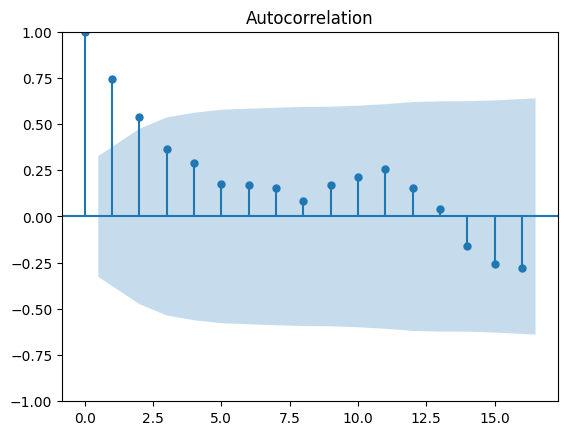

In [25]:
plot_acf(month_sample);

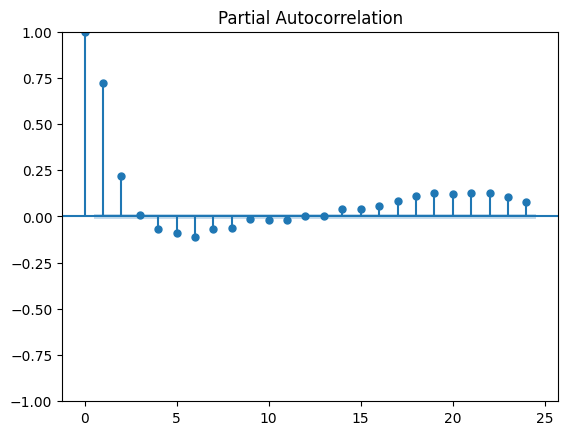

In [26]:
plot_pacf(station, lags=24);

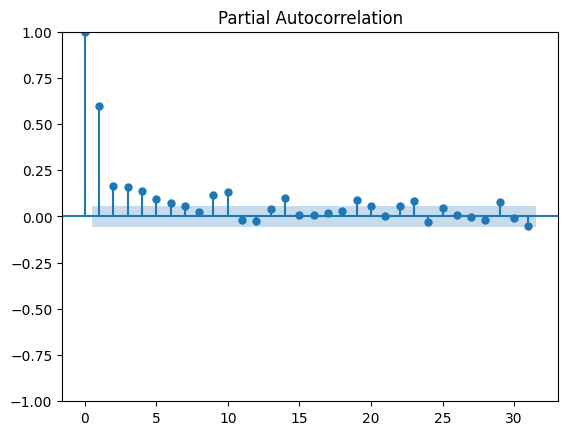

In [27]:
plot_pacf(day_sample, lags=31);

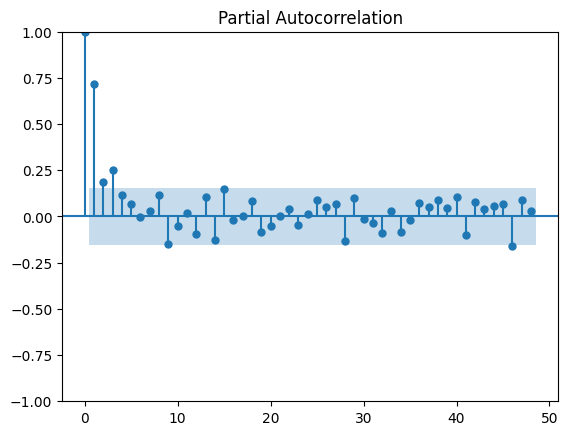

In [28]:
plot_pacf(week_sample, lags=48);

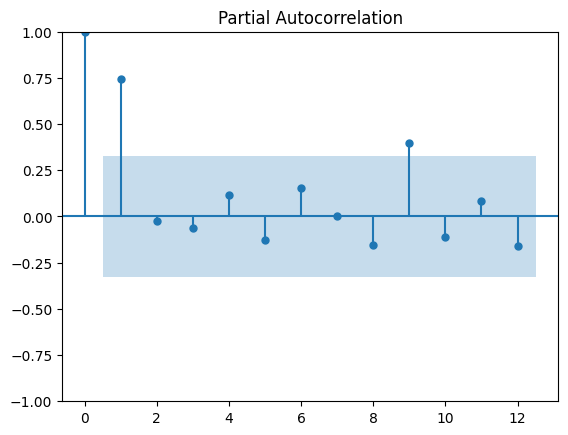

In [29]:
plot_pacf(month_sample, lags=12);

### Stationarity testing

In [30]:
adfuller(station)

(-11.609651341149279,
 2.5312105931587764e-21,
 49,
 26230,
 {'1%': -3.43059933054021,
  '5%': -2.861650196777599,
  '10%': -2.566828654483077},
 152087.50772863667)

* p-value is less than 0.05
* the hourly traffic is stationary

In [31]:
adfuller(day_sample)

(-2.510615193254707,
 0.1129128509387119,
 22,
 1072,
 {'1%': -3.4364647646486093,
  '5%': -2.864239892228526,
  '10%': -2.5682075189699822},
 4984.283173727471)

In [32]:
adfuller(day_sample.diff().dropna())

(-12.088811626269825,
 2.146283351720768e-22,
 21,
 1072,
 {'1%': -3.4364647646486093,
  '5%': -2.864239892228526,
  '10%': -2.5682075189699822},
 4983.862697647457)

In [33]:
adfuller(week_sample)

(-2.3792499522310457,
 0.14767880153031393,
 3,
 153,
 {'1%': -3.473829775724492,
  '5%': -2.880622899711496,
  '10%': -2.5769448985432954},
 521.2438408431469)

In [34]:
adfuller(week_sample.diff().dropna())

(-10.785057642067818,
 2.2050254650282924e-19,
 2,
 153,
 {'1%': -3.473829775724492,
  '5%': -2.880622899711496,
  '10%': -2.5769448985432954},
 521.2493860075348)

In [35]:
adfuller(month_sample)

(-2.1239134289679895,
 0.23500823359225792,
 0,
 35,
 {'1%': -3.6327426647230316,
  '5%': -2.9485102040816327,
  '10%': -2.6130173469387756},
 90.44499877676671)

monthly data is not stationary

In [36]:
adfuller(month_sample.diff().dropna())

(-6.444067814349998,
 1.581811471414384e-08,
 0,
 34,
 {'1%': -3.639224104416853,
  '5%': -2.9512301791166293,
  '10%': -2.614446989619377},
 91.16929634927114)